# 08 — EDA: all 4 vehicles merged (daily, heavy, moderate, rare)

**This notebook was missing before notebook 09 (the baseline model) — added retroactively because
you should never fit a model on data you haven't looked at first.** This is the all-vehicle
counterpart to `01_eda.ipynb` (which covers `heavy_user` only, for the separate single-vehicle
track). Same core questions, now compared across all 4 usage profiles: what does each vehicle's
raw data look like, how does the fault rate differ by profile, and does anything look inconsistent
enough to be worth flagging before modeling.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (12, 3.5), "axes.spines.top": False, "axes.spines.right": False})

SENSOR_COLS = ["SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
               "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure"]
CLASS_ORDER = ["Normal", "Warning", "Fault"]
PALETTE = {"Normal": "#3F7D5C", "Warning": "#D97706", "Fault": "#B23A2E"}
PROFILE_COLORS = {"daily_user": "#4C78A8", "heavy_user": "#B23A2E",
                   "moderate_user": "#F2A93B", "rare_user": "#54A24B"}


## 1. Load (from notebook 09's saved output — DTC already labeled)

In [2]:
df = pd.read_csv("../data/processed/all_vehicles_cleaned.csv", parse_dates=["timestamp"])
df = df.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)

print(f"{len(df):,} rows across {df['user_profile'].nunique()} vehicles")
print(df.groupby("user_profile")["timestamp"].agg(["min", "max", "count"]))


175,176 rows across 4 vehicles
                     min                 max  count
user_profile                                       
daily_user    2020-01-01 2024-12-29 17:00:00  43794
heavy_user    2020-01-01 2024-12-29 17:00:00  43794
moderate_user 2020-01-01 2024-12-29 17:00:00  43794
rare_user     2020-01-01 2024-12-29 17:00:00  43794


In [3]:
df.isna().sum().sum(), "total missing values across all columns"


(np.int64(0), 'total missing values across all columns')

## 2. Fault rate by usage profile — the comparison that matters most here

Fault_Label    Normal  Warning  Fault
user_profile                         
daily_user     98.792    0.096  1.112
heavy_user     97.246    0.180  2.573
moderate_user  98.507    0.114  1.379
rare_user      98.936    0.078  0.986


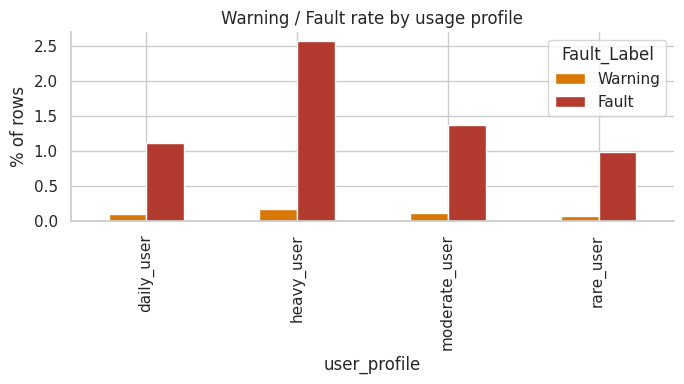

In [4]:
fault_rate_by_profile = (
    df.groupby("user_profile")["Fault_Label"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
    .reindex(columns=CLASS_ORDER)
    .round(3)
)
print(fault_rate_by_profile)

fault_rate_by_profile[["Warning", "Fault"]].plot(kind="bar", figsize=(7, 4),
                                                    color=["#D97706", "#B23A2E"])
plt.ylabel("% of rows")
plt.title("Warning / Fault rate by usage profile")
plt.tight_layout()
plt.show()


**Why this matters, plainly:** the 4 profiles do not have the same fault rate — this is exactly
the imbalance-across-groups issue flagged earlier in the project (same underlying finding as the
per-profile fairness check in the single-vehicle track's history, now visible directly in the raw
data before any model is even fit). Worth stating this explicitly rather than letting it surface
only after modeling.


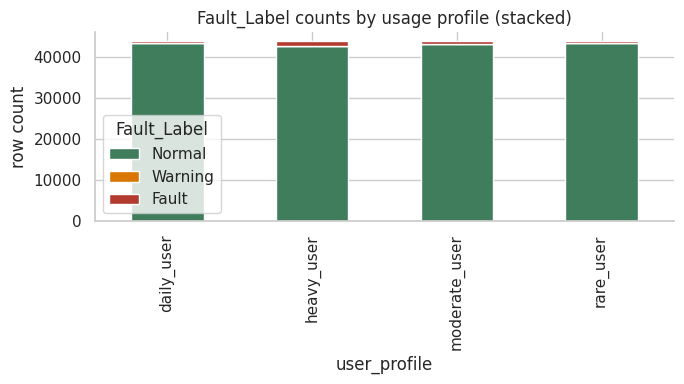

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df.groupby("user_profile")["Fault_Label"].value_counts().unstack().reindex(columns=CLASS_ORDER)
counts.plot(kind="bar", stacked=True, ax=ax, color=[PALETTE[c] for c in CLASS_ORDER])
ax.set_ylabel("row count")
ax.set_title("Fault_Label counts by usage profile (stacked)")
plt.tight_layout()
plt.show()


## 3. Sensor distributions — does each vehicle behave differently, or are they similar?

/sessions/tender-serene-goodall/tmp/ipykernel_9/2085588032.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, ax=ax, label=profile, color=PROFILE_COLORS[profile], linewidth=1.2)
/sessions/tender-serene-goodall/tmp/ipykernel_9/2085588032.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, ax=ax, label=profile, color=PROFILE_COLORS[profile], linewidth=1.2)
/sessions/tender-serene-goodall/tmp/ipykernel_9/2085588032.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, ax=ax, label=profile, color=PROFILE_COLORS[profile], linewidth=1.2)
/sessions/tender-serene-goodall/tmp/ipykernel_9/2085588032.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.

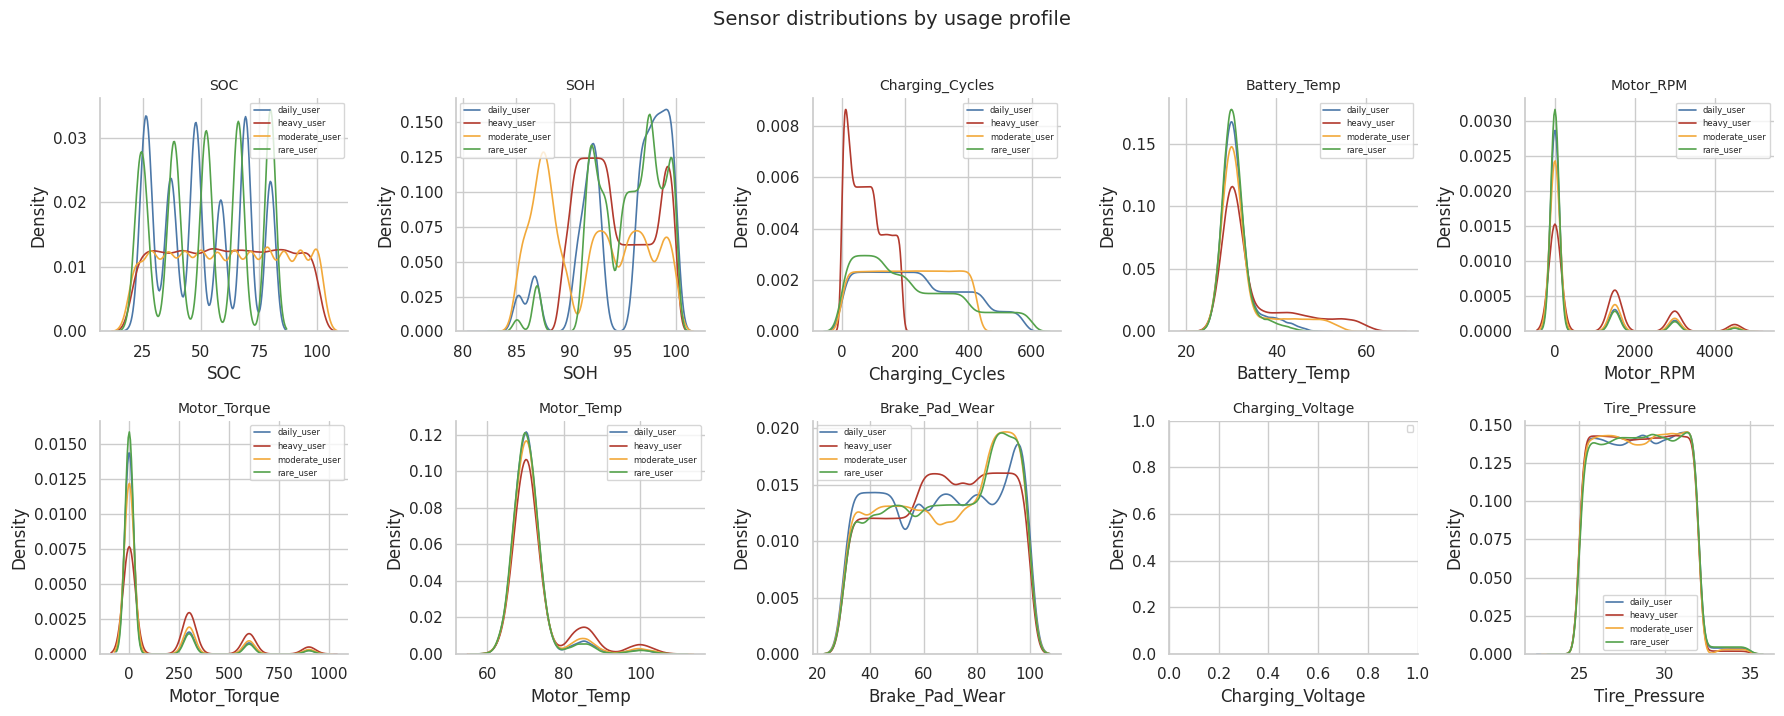

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, SENSOR_COLS):
    for profile in df["user_profile"].unique():
        subset = df[df["user_profile"] == profile][col]
        sns.kdeplot(subset, ax=ax, label=profile, color=PROFILE_COLORS[profile], linewidth=1.2)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=6)
fig.suptitle("Sensor distributions by usage profile", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Reading this:** if a sensor's distribution looks materially different across profiles (e.g.
`Motor_RPM` for `heavy_user` sitting well above the others), that's expected — it's what "usage
profile" is supposed to capture. If a sensor looks nearly identical across all 4 vehicles, it's
telling you that particular signal doesn't distinguish usage patterns, which is useful context for
later feature selection.


## 4. Full 5-year time series, all 4 vehicles overlaid — one representative sensor

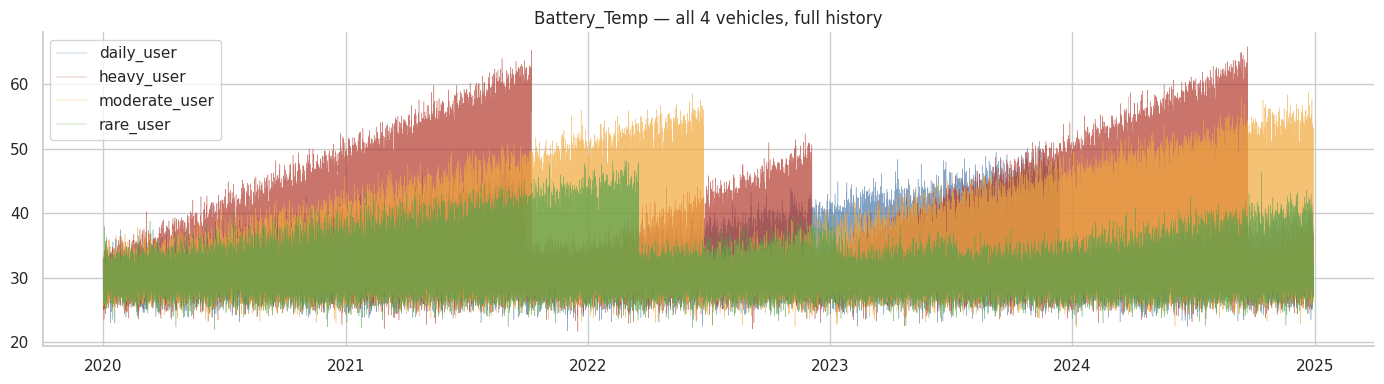

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
for profile in df["user_profile"].unique():
    subset = df[df["user_profile"] == profile]
    ax.plot(subset["timestamp"], subset["Battery_Temp"], linewidth=0.3,
             label=profile, color=PROFILE_COLORS[profile], alpha=0.7)
ax.set_title("Battery_Temp — all 4 vehicles, full history")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Correlation structure — is it consistent across vehicles, or does it change?

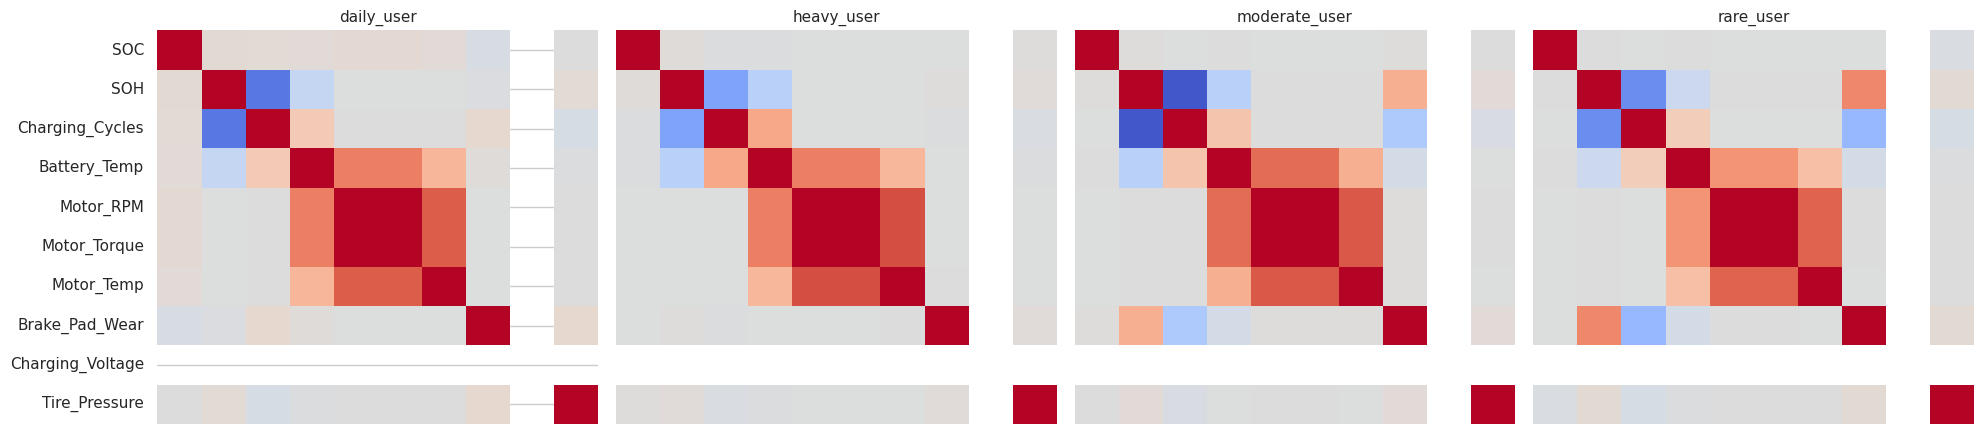

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, profile in zip(axes, df["user_profile"].unique()):
    corr = df[df["user_profile"] == profile][SENSOR_COLS].corr()
    sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, cbar=False,
                xticklabels=False, yticklabels=(ax == axes[0]))
    ax.set_title(profile, fontsize=11)
plt.tight_layout()
plt.show()


**Why check this:** if the correlation structure (e.g. `Motor_RPM` vs `Motor_Torque`) is
consistent across all 4 vehicles, that supports treating them as one pooled dataset for modeling.
If it looks very different per vehicle, that's evidence pooling them may hide real per-vehicle
differences — directly relevant to the tradeoff already flagged in `docs/Business_Goal_and_Process.md`
about merging all 4 profiles into one baseline.


## 6. Seasonality check — same as the single-vehicle EDA, now pooled

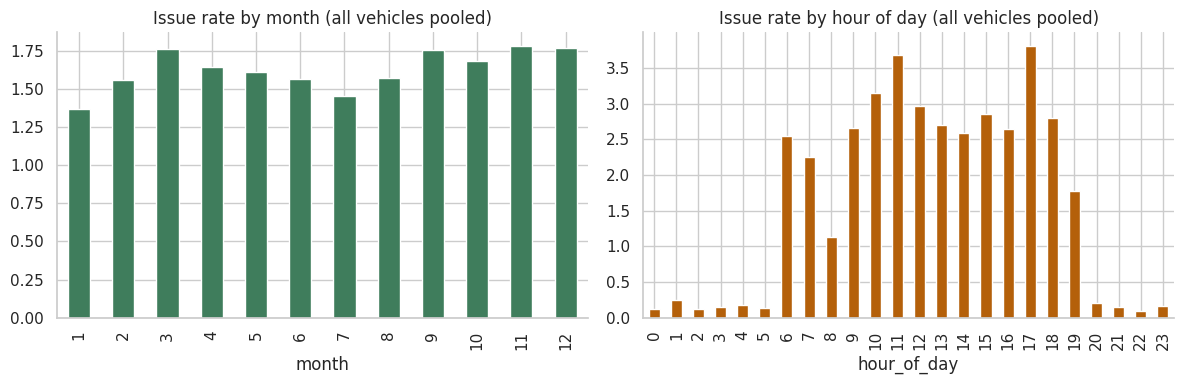

In [9]:
df["month"] = df["timestamp"].dt.month
df["hour_of_day"] = df["timestamp"].dt.hour
df["any_issue"] = df["Fault_Label"] != "Normal"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("month")["any_issue"].mean().mul(100).plot(kind="bar", ax=axes[0], color="#3F7D5C")
axes[0].set_title("Issue rate by month (all vehicles pooled)")
df.groupby("hour_of_day")["any_issue"].mean().mul(100).plot(kind="bar", ax=axes[1], color="#B4600A")
axes[1].set_title("Issue rate by hour of day (all vehicles pooled)")
plt.tight_layout()
plt.show()


## 7. What this notebook establishes, going into notebook 09 (baseline model)

In [10]:
print("Summary for the write-up:")
print(f"- {len(df):,} rows across 4 vehicles, {df.isna().sum().sum()} missing values (should be 0).")
print("- Fault/Warning rate by profile:")
print(fault_rate_by_profile[["Warning", "Fault"]])


Summary for the write-up:
- 175,176 rows across 4 vehicles, 0 missing values (should be 0).
- Fault/Warning rate by profile:
Fault_Label    Warning  Fault
user_profile                 
daily_user       0.096  1.112
heavy_user       0.180  2.573
moderate_user    0.114  1.379
rare_user        0.078  0.986


**Carried into notebook 09 onward:**
1. Confirmed clean data across all 4 vehicles, no missing values.
2. Fault rate genuinely differs by usage profile — flagged here as a known, visible property of the
   pooled dataset, not something the baseline model discovers by surprise later.
3. Sensor distributions and correlation structure compared across vehicles, giving a real basis for
   judging whether pooling them into one model (as the baseline does) is a reasonable simplification
   for this stage of the project.
